In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error

In [5]:
import pandas as pd

# -----------------------------
# Function to safely load CSV
# -----------------------------

def safe_load_csv(filename):
    df = pd.read_csv(filename)
    
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        print(f"{filename} loaded with date column parsed.")
    else:
        print(f"{filename} loaded (no date column detected).")
    
    print("Columns:", df.columns.tolist())
    print("Shape:", df.shape)
    print("-"*50)
    
    return df


# -----------------------------
# Load all datasets
# -----------------------------

df_air = safe_load_csv("air_quality_clean.csv")
df_temp = safe_load_csv("temperature_clean.csv")
df_health = safe_load_csv("health_clean.csv")
df_elec = safe_load_csv("electricity_clean.csv")
df_surface = safe_load_csv("urban_surface_clean.csv")
df_const = safe_load_csv("construction.csv")
df_budget = safe_load_csv("city_budget.csv")

air_quality_clean.csv loaded with date column parsed.
Columns: ['neighbourhood_id', 'date', 'population_density', 'building_density', 'pm25', 'pm10', 'no2', 'o3', 'aqi']
Shape: (1000000, 9)
--------------------------------------------------
temperature_clean.csv loaded with date column parsed.
Columns: ['neighbourhood_id', 'date', 'latitude', 'longitude', 'distance_from_center_km', 'tree_cover_pct', 'asphalt_pct', 'building_density', 'median_income', 'population_density', 'heat_retention_factor', 'infrastructure_quality_index', 'social_vulnerability_index', 'avg_temp', 'max_temp', 'night_temp', 'surface_temp', 'humidity', 'wind_speed', 'solar_radiation', 'urban_heat_index']
Shape: (1000000, 21)
--------------------------------------------------
health_clean.csv loaded with date column parsed.
Columns: ['neighbourhood_id', 'date', 'avg_temp', 'social_vulnerability_index', 'avg_temp_lag3', 'avg_temp_lag5', 'heat_fatigue_cases', 'dehydration_cases', 'hospital_admissions', 'heatstroke_deat

In [6]:
air_daily = df_air.groupby("date")[["pm25","aqi"]].mean().reset_index()
temp_daily = df_temp.groupby("date")[["avg_temp","humidity","wind_speed","surface_temp"]].mean().reset_index()
health_daily = df_health.groupby("date")[["heat_fatigue_cases","hospital_admissions"]].sum().reset_index()
elec_daily = df_elec.groupby("date")[["peak_load_kw"]].mean().reset_index()

In [7]:
df = air_daily.merge(temp_daily, on="date", how="left") \
              .merge(health_daily, on="date", how="left") \
              .merge(elec_daily, on="date", how="left")

df = df.sort_values("date")
df.set_index("date", inplace=True)
df = df.asfreq("D")

In [8]:
y = df["surface_temp"].dropna()

In [9]:
adf = adfuller(y)
print("ADF p-value:", adf[1])

ADF p-value: 0.0


In [10]:
y_diff = y.diff().dropna()

<Figure size 1200x400 with 0 Axes>

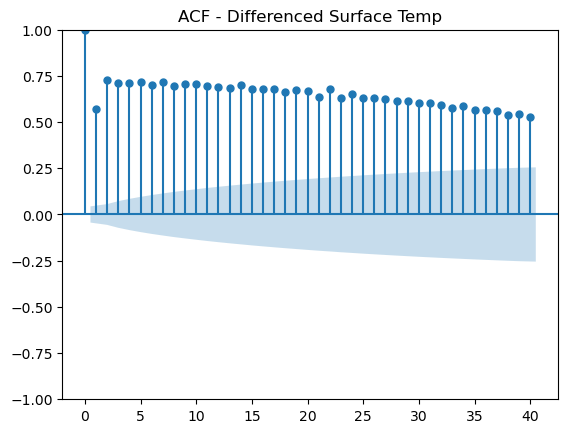

<Figure size 1200x400 with 0 Axes>

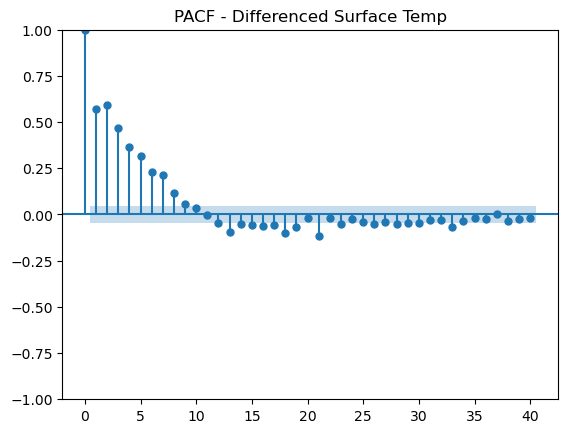

In [11]:
plt.figure(figsize=(12,4))
plot_acf(y_diff, lags=40)
plt.title("ACF - Differenced Surface Temp")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(y_diff, lags=40)
plt.title("PACF - Differenced Surface Temp")
plt.show()

In [12]:
train = y[:-30]
test = y[-30:]

model = SARIMAX(
    train,
    order=(1,1,1),              # adjust from PACF/ACF
    seasonal_order=(1,1,1,7),   # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      surface_temp   No. Observations:                 1970
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                2076.143
Date:                           Fri, 27 Feb 2026   AIC                          -4142.287
Time:                                   15:22:36   BIC                          -4114.401
Sample:                               01-01-2018   HQIC                         -4132.035
                                    - 05-24-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2770      0.049     -5.606      0.000      -0.374      -0.180
ma.L1         -0.2076      0.053     -3.908

In [13]:
forecast = results.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [14]:
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print("RMSE:", rmse)

RMSE: 0.4863238063542859


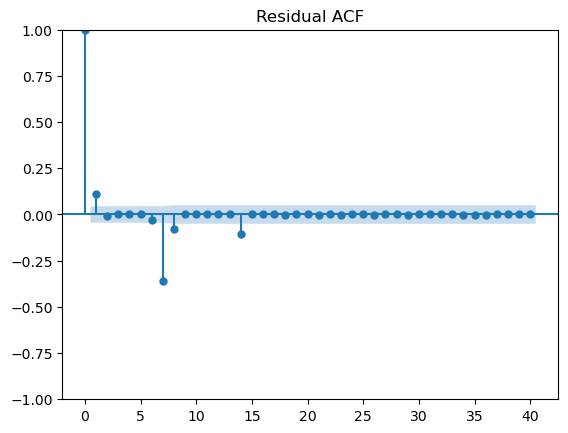

       lb_stat     lb_pvalue
10  293.040399  4.596226e-57


In [15]:
plot_acf(results.resid, lags=40)
plt.title("Residual ACF")
plt.show()

ljung = acorr_ljungbox(results.resid, lags=[10], return_df=True)
print(ljung)

In [17]:
print("Train NaNs:\n", train.isna().sum())
print("\nExog NaNs:\n", exog_vars[:-30].isna().sum())

Train NaNs:
 0

Exog NaNs:
 pm25                  0
humidity              0
peak_load_kw          6
heat_fatigue_cases    0
dtype: int64


In [18]:
# Combine target and exog first
model_df = df[["surface_temp","pm25","humidity","peak_load_kw","heat_fatigue_cases"]]

# Drop missing rows
model_df = model_df.dropna()

# Redefine target and exog
y = model_df["surface_temp"]
exog_vars = model_df[["pm25","humidity","peak_load_kw","heat_fatigue_cases"]]

# Train-test split AFTER cleaning
train = y[:-30]
test = y[-30:]

train_exog = exog_vars[:-30]
test_exog = exog_vars[-30:]

In [19]:
model = SARIMAX(
    train,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      surface_temp   No. Observations:                 1964
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                2049.837
Date:                           Fri, 27 Feb 2026   AIC                          -4081.674
Time:                                   15:24:43   BIC                          -4031.508
Sample:                               01-07-2018   HQIC                         -4063.229
                                    - 05-24-2023                                         
Covariance Type:                             opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
pm25                   0.0055      0.003      1.983      0.047    6.34e-05       0.011
humidity           

In [20]:
forecast = results.get_forecast(
    steps=30,
    exog=test_exog
)

forecast_mean = forecast.predicted_mean

In [25]:
# Fill missing values properly
y = y.ffill().bfill()
exog_vars = exog_vars.ffill().bfill()

In [26]:
print("Missing in y:", y.isna().sum())
print("Missing in exog:", exog_vars.isna().sum().sum())

Missing in y: 0
Missing in exog: 0


In [28]:
assert y.isna().sum() == 0
assert exog_vars.isna().sum().sum() == 0

In [31]:
print("Train missing:", train.isna().sum())
print("Train exog missing:", train_exog.isna().sum().sum())
print("Train length:", len(train))
print("Train exog length:", len(train_exog))

Train missing: 6
Train exog missing: 9
Train length: 1970
Train exog length: 1970


In [32]:
# Align y and exog properly
data = pd.concat([y, exog_vars], axis=1).dropna()

y_clean = data["risk_index"]
exog_clean = data[["pm25","humidity","peak_load_kw","heat_fatigue_cases"]]

train = y_clean[:-30]
test = y_clean[-30:]

train_exog = exog_clean[:-30]
test_exog = exog_clean[-30:]

In [33]:
model_data = pd.concat([y, exog_vars], axis=1)
model_data = model_data.dropna()

In [35]:
print("Length equal:", len(train) == len(train_exog))
print("Index equal:", train.index.equals(train_exog.index))
print("Endog missing:", train.isna().sum())
print("Exog missing:", train_exog.isna().sum().sum())

Length equal: True
Index equal: True
Endog missing: 0
Exog missing: 0


In [36]:
assert len(train) == len(train_exog)
assert train.index.equals(train_exog.index)
assert train.isna().sum() == 0
assert train_exog.isna().sum().sum() == 0

In [37]:
model = SARIMAX(
    train,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

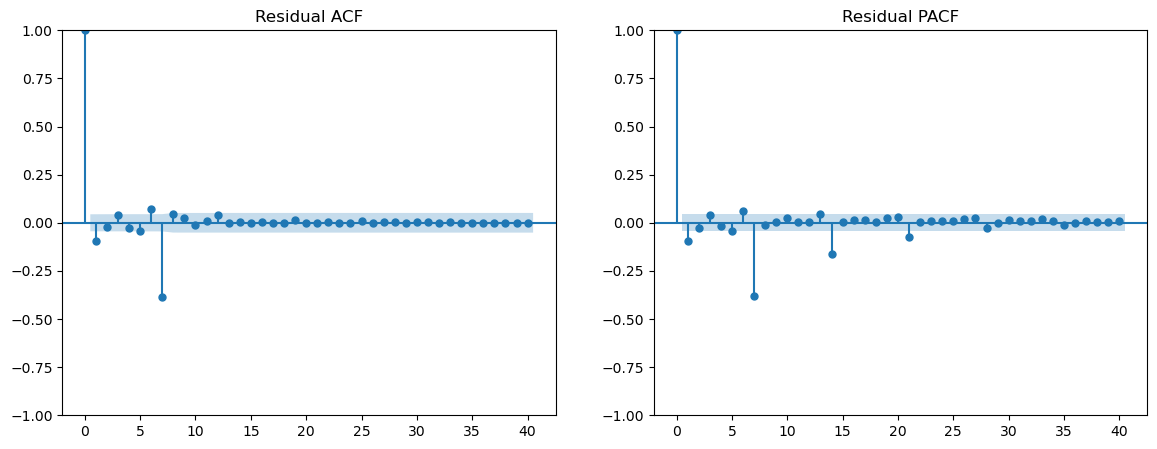

Test RMSE: 0.23771142884589977


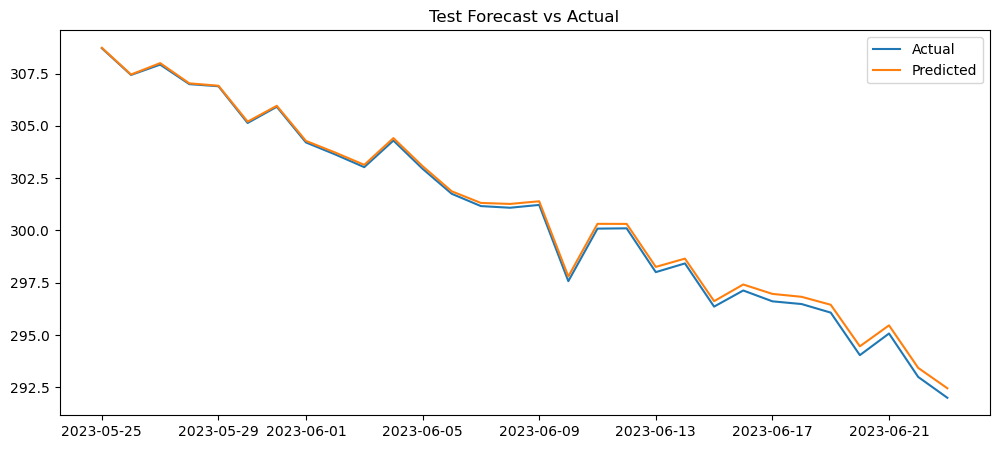

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =========================================================
# RESIDUAL DIAGNOSTICS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(results.resid, lags=40, ax=axes[0])
axes[0].set_title("Residual ACF")

plot_pacf(results.resid, lags=40, ax=axes[1])
axes[1].set_title("Residual PACF")

plt.show()


# =========================================================
# TEST FORECAST PLOT
# =========================================================

forecast_test = results.get_forecast(steps=30, exog=test_exog)
pred_test = forecast_test.predicted_mean

rmse = np.sqrt(mean_squared_error(test, pred_test))
print("Test RMSE:", rmse)

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, pred_test, label="Predicted")
plt.title("Test Forecast vs Actual")
plt.legend()
plt.show()

Characteristic Modal

In [49]:
# =====================================================
# FINAL STRUCTURAL (CHARACTERISTIC) RISK MODEL
# =====================================================

import pandas as pd
import statsmodels.api as sm

# -----------------------------------------------------
# 1. Create risk_index if not already created
# -----------------------------------------------------
if "risk_index" not in df.columns:
    df["risk_index"] = (
        0.4 * df["pm25"] +
        0.3 * df["avg_temp"] +
        0.2 * df["humidity"] +
        0.1 * df["peak_load_kw"]
    )

# -----------------------------------------------------
# 2. Compute average risk per neighbourhood
# -----------------------------------------------------
risk_neigh = (
    df.groupby("neighbourhood_id")["risk_index"]
      .mean()
      .reset_index()
)

# -----------------------------------------------------
# 3. Merge structural characteristics
# -----------------------------------------------------
df_struct = df_surface.merge(
    risk_neigh,
    on="neighbourhood_id",
    how="left"
)

# -----------------------------------------------------
# 4. Check available columns (IMPORTANT)
# -----------------------------------------------------
print("Available columns in structural dataset:")
print(df_struct.columns)

# -----------------------------------------------------
# 5. Select structural variables
# (MAKE SURE THESE COLUMN NAMES EXIST)
# -----------------------------------------------------
X = df_struct[[
    "tree_cover_pct",
    "asphalt_pct",
    "building_density",
    "population_density",
    "median_income"
]]

y = df_struct["risk_index"]

# -----------------------------------------------------
# 6. Clean data
# -----------------------------------------------------
data = pd.concat([X, y], axis=1).dropna()

X_clean = data.drop("risk_index", axis=1)
y_clean = data["risk_index"]

# Add intercept
X_clean = sm.add_constant(X_clean)

# -----------------------------------------------------
# 7. Fit Structural Model
# -----------------------------------------------------
model_struct = sm.OLS(y_clean, X_clean).fit()

# -----------------------------------------------------
# 8. Show Results
# -----------------------------------------------------
print(model_struct.summary())

Available columns in structural dataset:
Index(['neighbourhood_id', 'latitude', 'longitude', 'distance_from_center_km',
       'tree_cover_pct', 'asphalt_pct', 'building_density', 'median_income',
       'population_density', 'heat_retention_factor',
       'infrastructure_quality_index', 'social_vulnerability_index',
       'risk_index'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:             risk_index   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.160e+04
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:14:57   Log-Likelihood:                -1076.8
No. Observations:                 500   AIC:                             2166.
Df Residuals:                     494   BIC:                             2191.
Df M